In [ ]:
import pandas as pd

df = pd.read_csv("Resume.csv")

In [ ]:
print(df.shape)
print(df.columns)

(2484, 4)
Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')


In [ ]:
import re
import nltk

nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'http\S+', ' ', text)

    text = re.sub(r'www\S+', ' ', text)

    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [ ]:
df['clean_resume'] = df['Resume_str'].apply(clean_text)

In [ ]:
df[['Category','clean_resume']].head()

,Category,clean_resume
0,HR,hr administrator marketing associate hr admini...
1,HR,hr specialist us hr operations summary versati...
2,HR,hr director summary years experience recruitin...
3,HR,hr specialist summary dedicated driven dynamic...
4,HR,hr manager skill highlights hr skills hr depar...


In [ ]:
skills_db = [

    'python',
    'java',
    'c++',
    'sql',
    'mysql',
    'postgresql',

    'machine learning',
    'deep learning',
    'nlp',
    'data science',

    'tensorflow',
    'pytorch',
    'scikit-learn',

    'pandas',
    'numpy',

    'tableau',
    'power bi',
    'excel',

    'aws',
    'azure',

    'docker',
    'git',
    'linux'
]

In [ ]:
def extract_skills(text):

    text = text.lower()

    found_skills = []

    for skill in skills_db:

        if skill.lower() in text:
            found_skills.append(skill)

    return list(set(found_skills))

In [ ]:
df['skills'] = df['clean_resume'].apply(extract_skills)

In [ ]:
df[['Category','skills']].head(10)

,Category,skills
0,HR,[aws]
1,HR,[git]
2,HR,[excel]
3,HR,[excel]
4,HR,"[aws, excel]"
5,HR,[excel]
6,HR,[]
7,HR,[aws]
8,HR,"[aws, excel]"
9,HR,[aws]


In [ ]:
df[df['skills'].apply(len) > 3][['Category','skills']].head(10)

,Category,skills
91,HR,"[aws, linux, sql, java, excel]"
120,DESIGNER,"[sql, mysql, git, java]"
124,DESIGNER,"[sql, mysql, git, java]"
126,DESIGNER,"[python, linux, excel, git]"
128,DESIGNER,"[python, linux, mysql, sql, java]"
250,INFORMATION-TECHNOLOGY,"[sql, azure, linux, tableau]"
263,INFORMATION-TECHNOLOGY,"[aws, linux, sql, mysql, excel]"
267,INFORMATION-TECHNOLOGY,"[python, sql, excel, git]"
280,INFORMATION-TECHNOLOGY,"[sql, mysql, linux, java]"
281,INFORMATION-TECHNOLOGY,"[sql, mysql, linux, java]"


In [ ]:
job_description = """

Data Scientist

Required Skills:

Python
Machine Learning
SQL
Pandas
Numpy
AWS
NLP

"""

In [ ]:
job_description = clean_text(job_description)

print(job_description)

data scientist required skills python machine learning sql pandas numpy aws nlp


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

In [ ]:
resume_vectors = vectorizer.fit_transform(
    df['clean_resume']
)

In [ ]:
job_vector = vectorizer.transform(
    [job_description]
)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
scores = cosine_similarity(
    job_vector,
    resume_vectors
)

In [ ]:
import numpy as np

max_score = np.max(scores)

df['score'] = np.round(
    (scores.flatten() / max_score) * 100,
    2
)

In [ ]:
def recommendation(score):

    if score >= 80:
        return "Strong Match"

    elif score >= 60:
        return "Consider"

    else:
        return "Reject"

ranked['recommendation'] = ranked['score'].apply(
    recommendation
)

In [ ]:
print(df.columns)

Index(['ID', 'Resume_str', 'Resume_html', 'Category', 'clean_resume', 'skills',
       'score'],
      dtype='object')


In [ ]:
ranked = df.sort_values(
    by='score',
    ascending=False
)

In [ ]:
ranked[
    ['ID','Category','score']
].head(10)

,ID,Category,score
926,62994611,AGRICULTURE,15.059751
1339,18448085,AUTOMOBILE,14.206367
1762,12011623,ENGINEERING,13.630246
298,20824105,INFORMATION-TECHNOLOGY,12.910937
1218,21156767,CONSULTANT,11.490306
1142,30863060,CONSULTANT,11.485518
929,11813872,AGRICULTURE,9.574730
2153,34953092,BANKING,8.764923
1303,42156237,DIGITAL-MEDIA,8.094512
229,36434348,INFORMATION-TECHNOLOGY,7.884964


In [ ]:
ranked['recommendation'] = ranked['score'].apply(
    recommendation
)

In [ ]:
ranked[
[
'ID',
'Category',
'score',
'recommendation'
]
].head(10)

,ID,Category,score,recommendation
926,62994611,AGRICULTURE,15.059751,Reject
1339,18448085,AUTOMOBILE,14.206367,Reject
1762,12011623,ENGINEERING,13.630246,Reject
298,20824105,INFORMATION-TECHNOLOGY,12.910937,Reject
1218,21156767,CONSULTANT,11.490306,Reject
1142,30863060,CONSULTANT,11.485518,Reject
929,11813872,AGRICULTURE,9.574730,Reject
2153,34953092,BANKING,8.764923,Reject
1303,42156237,DIGITAL-MEDIA,8.094512,Reject
229,36434348,INFORMATION-TECHNOLOGY,7.884964,Reject


In [ ]:
required_skills = extract_skills(job_description)

def missing_skills(candidate_skills):

    return list(
        set(required_skills) -
        set(candidate_skills)
    )

df['missing_skills'] = df['skills'].apply(
    missing_skills
)

def recommendation(score):

    if score >= 80:
        return "Strong Match"

    elif score >= 60:
        return "Consider"

    else:
        return "Reject"

df['recommendation'] = df['score'].apply(
    recommendation
)

ranked = df.sort_values(
    by='score',
    ascending=False
)

In [ ]:
print(ranked.columns)

Index(['ID', 'Resume_str', 'Resume_html', 'Category', 'clean_resume', 'skills',
       'score', 'missing_skills', 'recommendation'],
      dtype='object')


In [ ]:
required_skills = extract_skills(job_description)

print(required_skills)

['python', 'aws', 'nlp', 'sql', 'pandas', 'machine learning', 'numpy']


In [ ]:
def missing_skills(candidate_skills):

    return list(
        set(required_skills) -
        set(candidate_skills)
    )

In [ ]:
ranked['missing_skills'] = ranked['skills'].apply(
    missing_skills
)

In [ ]:
ranked[
[
'ID',
'Category',
'score',
'recommendation',
'skills',
'missing_skills'
]
].head(10)

,ID,Category,score,recommendation,skills,missing_skills
926,62994611,AGRICULTURE,15.059751,Reject,"[python, tensorflow, sql, pandas, java, excel,...","[aws, nlp, numpy, machine learning]"
1339,18448085,AUTOMOBILE,14.206367,Reject,"[python, data science, sql, pandas, mysql, exc...","[aws, nlp, machine learning]"
1762,12011623,ENGINEERING,13.630246,Reject,"[python, sql, pandas, machine learning, excel,...","[aws, nlp, numpy]"
298,20824105,INFORMATION-TECHNOLOGY,12.910937,Reject,"[python, linux, aws]","[nlp, sql, pandas, machine learning, numpy]"
1218,21156767,CONSULTANT,11.490306,Reject,"[python, data science, mysql, sql, java, azure...","[aws, nlp, pandas, numpy]"
1142,30863060,CONSULTANT,11.485518,Reject,"[sql, tableau, excel, java]","[python, aws, nlp, pandas, machine learning, n..."
929,11813872,AGRICULTURE,9.574730,Reject,"[python, data science, aws, sql, pandas, java]","[nlp, numpy, machine learning]"
2153,34953092,BANKING,8.764923,Reject,"[python, sql, machine learning]","[aws, nlp, pandas, numpy]"
1303,42156237,DIGITAL-MEDIA,8.094512,Reject,"[python, git, mysql, sql, java, power bi, exce...","[aws, nlp, pandas, machine learning, numpy]"
229,36434348,INFORMATION-TECHNOLOGY,7.884964,Reject,[sql],"[python, aws, nlp, pandas, machine learning, n..."


In [ ]:
import numpy as np

max_score = np.max(scores)

df['score'] = np.round(
    (scores.flatten() / max_score) * 100,
    2
)

In [ ]:
ranked[['ID','score']].head()

,ID,score
926,62994611,15.059751
1339,18448085,14.206367
1762,12011623,13.630246
298,20824105,12.910937
1218,21156767,11.490306


In [ ]:
top5 = ranked.head(5)

for index, row in top5.iterrows():

    print("="*60)

    print("Candidate ID:", row['ID'])

    print("Category:", row['Category'])

    print("Score:", round(row['score'],2))

    print("Skills Found:", row['skills'])

    print("Missing Skills:", row['missing_skills'])

    print("="*60)

Candidate ID: 62994611
Category: AGRICULTURE
Score: 15.06
Skills Found: ['python', 'tensorflow', 'sql', 'pandas', 'java', 'excel', 'tableau']
Missing Skills: ['aws', 'nlp', 'numpy', 'machine learning']
Candidate ID: 18448085
Category: AUTOMOBILE
Score: 14.21
Skills Found: ['python', 'data science', 'sql', 'pandas', 'mysql', 'excel', 'numpy', 'tableau']
Missing Skills: ['aws', 'nlp', 'machine learning']
Candidate ID: 12011623
Category: ENGINEERING
Score: 13.63
Skills Found: ['python', 'sql', 'pandas', 'machine learning', 'excel', 'tableau']
Missing Skills: ['aws', 'nlp', 'numpy']
Candidate ID: 20824105
Category: INFORMATION-TECHNOLOGY
Score: 12.91
Skills Found: ['python', 'linux', 'aws']
Missing Skills: ['nlp', 'sql', 'pandas', 'machine learning', 'numpy']
Candidate ID: 21156767
Category: CONSULTANT
Score: 11.49
Skills Found: ['python', 'data science', 'mysql', 'sql', 'java', 'azure', 'machine learning']
Missing Skills: ['aws', 'nlp', 'pandas', 'numpy']


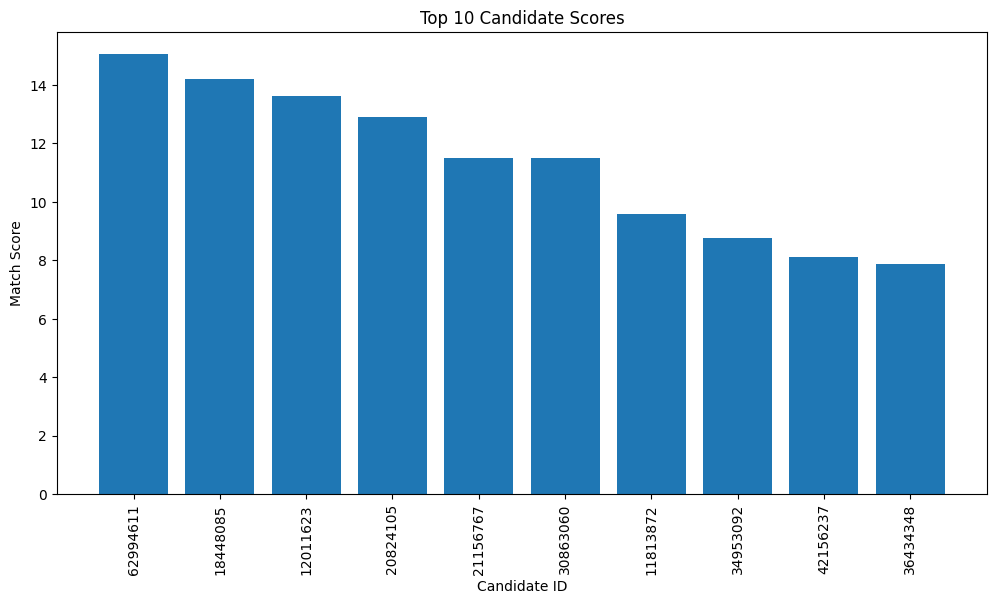

In [ ]:
import matplotlib.pyplot as plt

top10 = ranked.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10['ID'].astype(str),
    top10['score']
)

plt.xticks(rotation=90)

plt.title("Top 10 Candidate Scores")

plt.xlabel("Candidate ID")

plt.ylabel("Match Score")

plt.show()

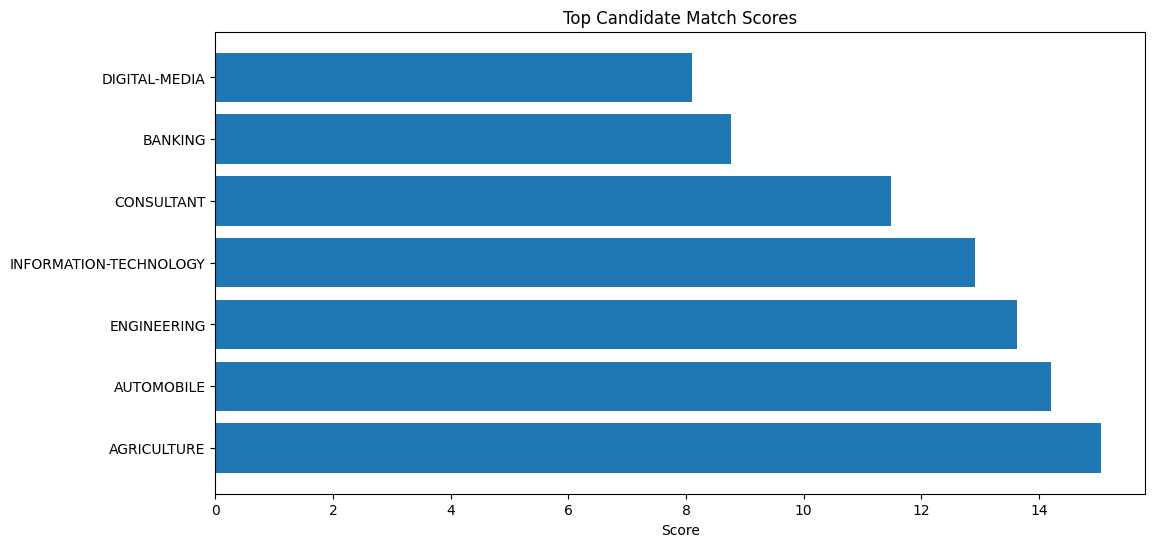

In [ ]:
top10 = ranked.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10['Category'],
    top10['score']
)

plt.title(
    "Top Candidate Match Scores"
)

plt.xlabel("Score")

plt.show()

In [ ]:
ranked.to_csv(
    "ranked_candidates_final.csv",
    index=False
)

print("CSV Saved Successfully")

CSV Saved Successfully


In [ ]:
from google.colab import files

files.download(
    "ranked_candidates_final.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
ranked[
[
'ID',
'Category',
'score',
'recommendation',
'skills',
'missing_skills'
]
].head(10)

,ID,Category,score,recommendation,skills,missing_skills
926,62994611,AGRICULTURE,15.059751,Reject,"[python, tensorflow, sql, pandas, java, excel,...","[aws, nlp, numpy, machine learning]"
1339,18448085,AUTOMOBILE,14.206367,Reject,"[python, data science, sql, pandas, mysql, exc...","[aws, nlp, machine learning]"
1762,12011623,ENGINEERING,13.630246,Reject,"[python, sql, pandas, machine learning, excel,...","[aws, nlp, numpy]"
298,20824105,INFORMATION-TECHNOLOGY,12.910937,Reject,"[python, linux, aws]","[nlp, sql, pandas, machine learning, numpy]"
1218,21156767,CONSULTANT,11.490306,Reject,"[python, data science, mysql, sql, java, azure...","[aws, nlp, pandas, numpy]"
1142,30863060,CONSULTANT,11.485518,Reject,"[sql, tableau, excel, java]","[python, aws, nlp, pandas, machine learning, n..."
929,11813872,AGRICULTURE,9.574730,Reject,"[python, data science, aws, sql, pandas, java]","[nlp, numpy, machine learning]"
2153,34953092,BANKING,8.764923,Reject,"[python, sql, machine learning]","[aws, nlp, pandas, numpy]"
1303,42156237,DIGITAL-MEDIA,8.094512,Reject,"[python, git, mysql, sql, java, power bi, exce...","[aws, nlp, pandas, machine learning, numpy]"
229,36434348,INFORMATION-TECHNOLOGY,7.884964,Reject,[sql],"[python, aws, nlp, pandas, machine learning, n..."


In [ ]:
print(ranked['score'].describe())

count    2484.000000
mean        0.792528
std         1.185466
min         0.000000
25%         0.180919
50%         0.428681
75%         0.910243
max        15.059751
Name: score, dtype: float64


In [ ]:
def recommendation(score):

    if score >= 13:
        return "Strong Match"

    elif score >= 10:
        return "Consider"

    else:
        return "Reject"



In [ ]:
ranked['recommendation'] = ranked['score'].apply(
    recommendation
)

In [ ]:
ranked[
['ID','Category','score','recommendation']
].head(20)

,ID,Category,score,recommendation
926,62994611,AGRICULTURE,15.059751,Strong Match
1339,18448085,AUTOMOBILE,14.206367,Strong Match
1762,12011623,ENGINEERING,13.630246,Strong Match
298,20824105,INFORMATION-TECHNOLOGY,12.910937,Consider
1218,21156767,CONSULTANT,11.490306,Consider
1142,30863060,CONSULTANT,11.485518,Consider
929,11813872,AGRICULTURE,9.574730,Reject
2153,34953092,BANKING,8.764923,Reject
1303,42156237,DIGITAL-MEDIA,8.094512,Reject
229,36434348,INFORMATION-TECHNOLOGY,7.884964,Reject


In [ ]:
high = ranked['score'].quantile(0.75)
medium = ranked['score'].quantile(0.50)

def recommendation(score):

    if score >= high:
        return "Strong Match"

    elif score >= medium:
        return "Consider"

    else:
        return "Reject"

In [ ]:
ranked[
['ID','Category','score','recommendation']
].head(20)

,ID,Category,score,recommendation
926,62994611,AGRICULTURE,15.059751,Strong Match
1339,18448085,AUTOMOBILE,14.206367,Strong Match
1762,12011623,ENGINEERING,13.630246,Strong Match
298,20824105,INFORMATION-TECHNOLOGY,12.910937,Consider
1218,21156767,CONSULTANT,11.490306,Consider
1142,30863060,CONSULTANT,11.485518,Consider
929,11813872,AGRICULTURE,9.574730,Reject
2153,34953092,BANKING,8.764923,Reject
1303,42156237,DIGITAL-MEDIA,8.094512,Reject
229,36434348,INFORMATION-TECHNOLOGY,7.884964,Reject
